In [25]:
import gdsfactory as gf
from ihp import PDK
from ihp.cells.capacitors import rfcmim
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
#yaml_file = Path("~/Documents/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()
yaml_file = Path("~/projects/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

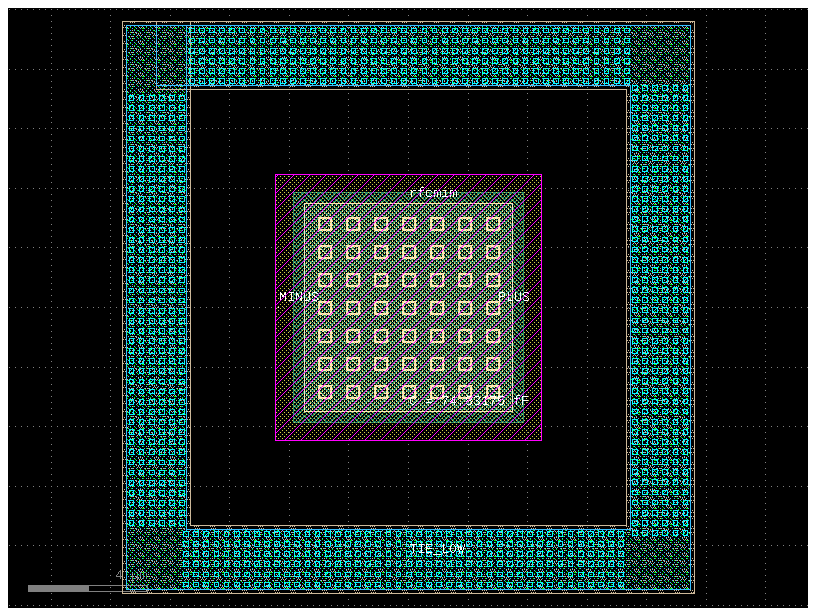

In [26]:
c = rfcmim(width=7.0, length=7.0)
c_plot = gf.Component()
for layer in c.layers:
    layer_number, datatype = layer
    if datatype != 0:
        continue
    layer_comp = c.extract(layers=[layer])
    c_plot.add_ref(layer_comp)

c_plot.draw_ports()
c_plot.plot()

In [27]:
cc = gf.Component()

layers_to_keep = [
    "Metal1pin",
    "Activdrawing",
    #"Contdrawing",
    "Metal1drawing",
    "pSDdrawing",
    "MIMdrawing",
    "Metal5drawing",
    "Metal5pin",
    "MemCapdrawing",
    "TopMetal1drawing",
    "TopMetal1pin",
    "Vmimdrawing",    
]

for layer in layers_to_keep:
    extracted = c.extract(layers=[layer])

    if not extracted.get_polygons():
        continue

    # Merge overlapping polygons on this layer
    merged = gf.boolean(
        A=extracted,
        B=extracted,
        operation="or",
        layer=layer,
    )

    cc.add_ref(merged)

cc.flatten()
cc.add_ports(c.ports)

In [ ]:
# Checking the port layers.
cc.ports

["Port(self.name='MINUS', self.width=200, trans=r180 *1 -4.36,0, layer=Metal5pin (67/2), port_type=electrical)", "Port(self.name='PLUS', self.width=1000, trans=r0 *1 3,0, layer=TopMetal1pin (126/2), port_type=electrical)", "Port(self.name='TIE_LOW', self.width=2000, trans=r0 *1 0,-8.46, layer=Metal1pin (8/2), port_type=electrical)"]

In [ ]:
sim = DrivenSim()
sim.set_output_dir("runs/palace-sim-rfcmim")
sim.set_geometry(cc)

sim.set_stack(substrate_thickness=2.0,air_above=5.0)

# MINUS is assigned as P1 by gdsfactory (component port order), so it must be
# excited=True to ensure Palace excites P1 and generates S[1][1] and S[2][1].
sim.add_port("MINUS", from_layer="metal5", to_layer="topmetal1", geometry="via", excited=True)
sim.add_port("PLUS", from_layer="metal5", to_layer="topmetal1", geometry="via", excited=False)

# TIE_LOW is a substrate tie pin and is not included as a port — adding it causes
# "Invalid boundary mesh (overlapping facets)" during meshing, likely because its
# surface overlaps with nearby metal geometry near the component boundary.

#sim.add_port("TIE_LOW", layer="metal1", length=2.0, geometry="inplane", excited=False)

sim.set_driven(fmin=1e9, fmax=20e9, num_points=21)

print(sim.validate_config())

Validation: PASSED


In [ ]:
# If we try to mesh the geometry with planar_conductors=False, we get the following error:
# Error   : Unknown model face with tag 27
sim.mesh(preset="graded",margin=1.0, refined_mesh_size=0.2,planar_conductors=True)

Mesh Summary
Dimensions: 21.2 x 21.2 x 23.3 µm
Nodes:      8,953
Elements:   60,538
Tetrahedra: 49,353
Edge length: 0.03 - 14.99 µm
Quality:    0.608 (min: 0.008)
SICN:       0.652 (all valid)
----------------------------------------
Volumes (3):
  - SiO2 [1]
  - passive [2]
  - air [3]
Surfaces (12):
  - active_pec [4]
  - metal5_pec [5]
  - metal1_pec [6]
  - topmetal1_pec [7]
  - vmim_pec [8]
  - P1 [9]
  - P2 [10]
  - SiO2__None [11]
  - SiO2__passive [12]
  - passive__None [13]
  - air__passive [14]
  - air__None [15]
----------------------------------------
Mesh:   runs/palace-sim-rfcmim/palace.msh

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:21:54.016 (  77.085s) [    76306C836080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:21:54.025 (  77.094s) [    76306C836080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-17 16:21:54.063 (  77.132s) [    76306C836080]vt

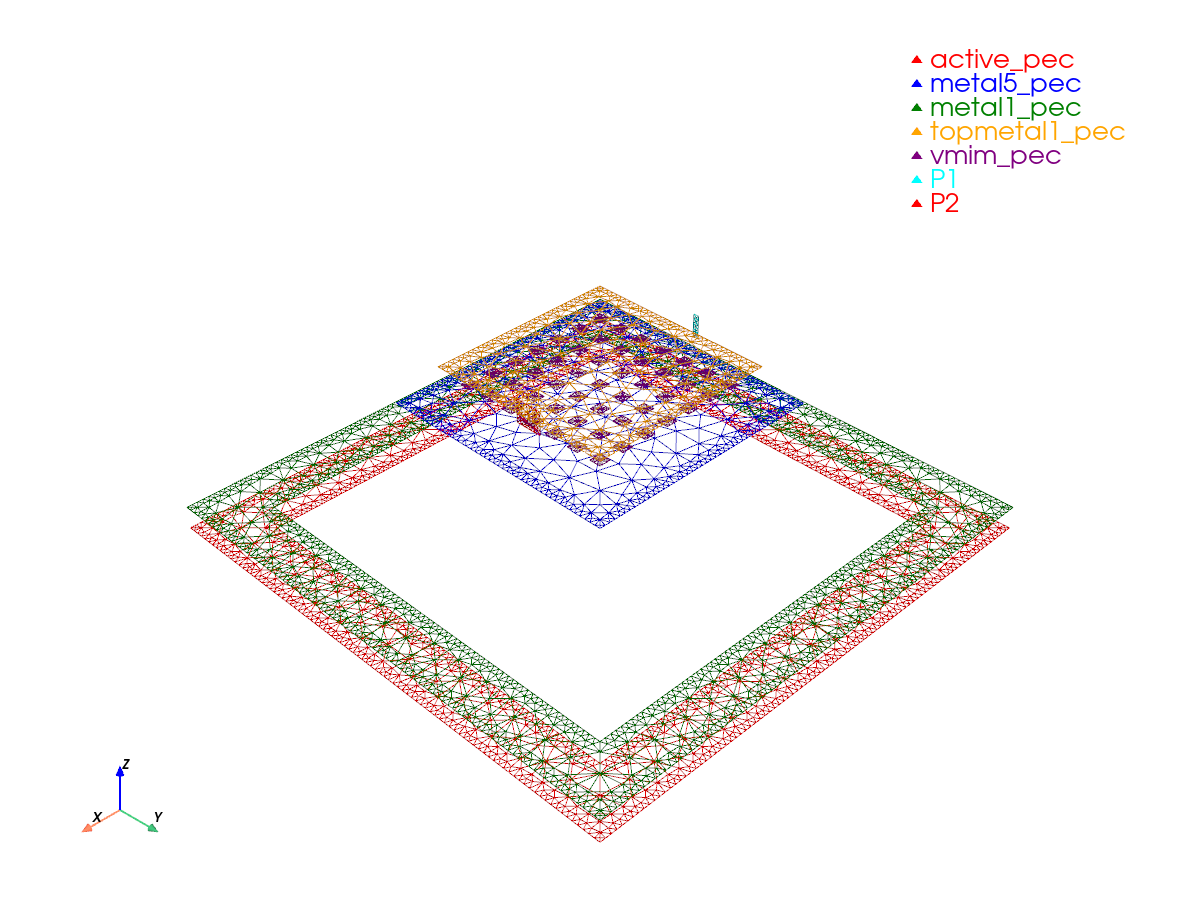

In [31]:
sim.plot_mesh(show_groups=["metal","active","vmim","P"],interactive=False)

In [32]:
results = sim.run(parent_dir="runs")

  palace-d263fbe5  completed  0m 52s
Extracting results.tar.gz...
Downloaded 6 files to /home/delfina/projects/gsim/nbs/IHP_components/sim-data-palace-d263fbe5


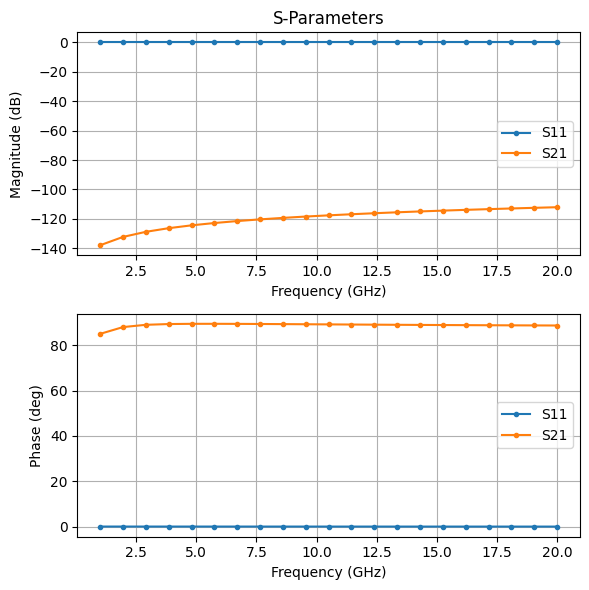

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(results["port-S.csv"])
df.columns = df.columns.str.strip()  # Remove whitespace from column names

freq = df["f (GHz)"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

# Magnitude plot
ax1.plot(freq, df["|S[1][1]| (dB)"], marker=".", label="S11")
ax1.plot(freq, df["|S[2][1]| (dB)"], marker=".", label="S21")
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("S-Parameters")
ax1.legend()
ax1.grid(True)

# Phase plot
ax2.plot(freq, df["arg(S[1][1]) (deg.)"], marker=".", label="S11")
ax2.plot(freq, df["arg(S[2][1]) (deg.)"], marker=".", label="S21")
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Phase (deg)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()